In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from xgboost_classifier import XGBoostClassifier

In [2]:
# 1. Generate Data
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

In [3]:
# 2. Train (Lambda=1.0 provides smoothing)
clf = XGBoostClassifier(n_estimators=50, learning_rate=0.1, max_depth=4, reg_lambda=1.0)
clf.fit(X, y)

In [4]:
# 3. Meshgrid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),np.arange(y_min, y_max, 0.05))

In [5]:
# 4. Predict
Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

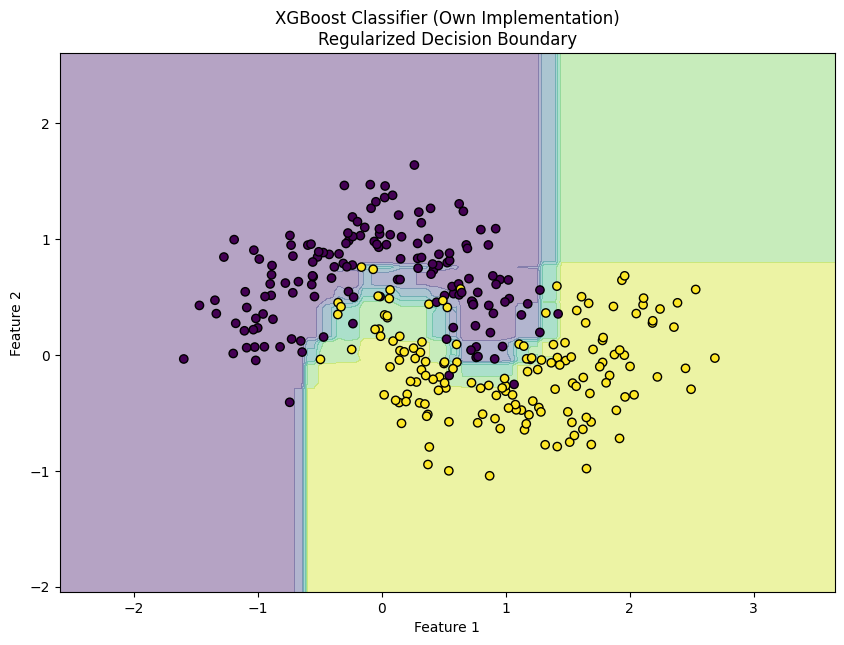

In [6]:
# 5. Plot
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k')
plt.title(f"XGBoost Classifier (Own Implementation)\nRegularized Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()